# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Step 2: Load the Dataset

In [5]:
titanic = pd.read_csv('titanic.csv')


# Step 3: Data Exploration

In [8]:
# Check the first few rows of the dataset
print(titanic.head())

# Check the summary of the dataset
print(titanic.info())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

# Step 4: Data Cleaning

#4.1 Handling Missing Age Data:

In [12]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())


#4.2 Handling Missing Embarked Data:

In [15]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])


#4.3 Handling Missing Fare Data (if applicable):

In [18]:
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())


# Step 5: Data Encoding

In [21]:
# One-Hot Encoding for 'Embarked' column
titanic = pd.get_dummies(titanic, columns=['Embarked'], drop_first=True)


In [23]:
titanic['Sex'] = titanic['Sex'].map({'male': 1, 'female': 0})


# Step 6: Exploratory Data Analysis (EDA)

#6.1 Distribution of Numerical Features

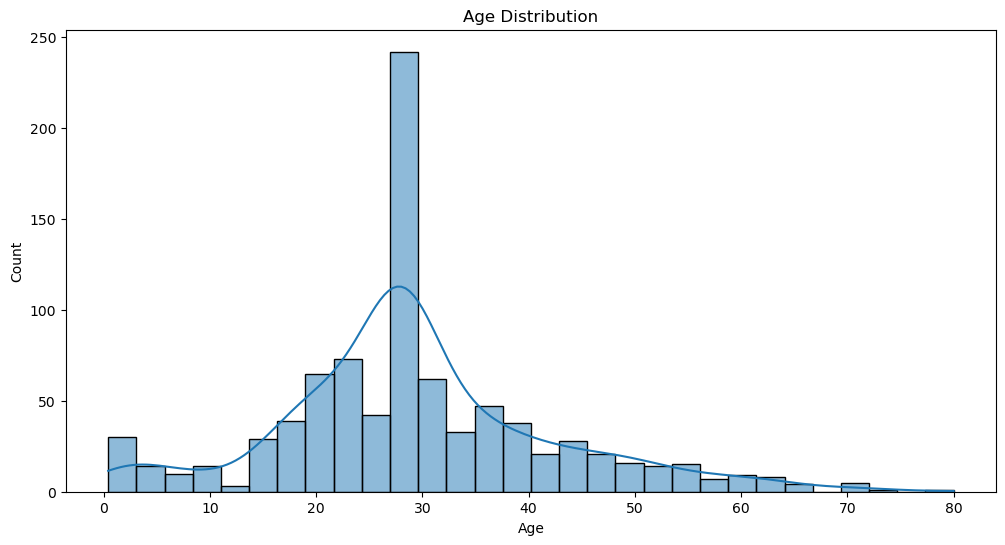

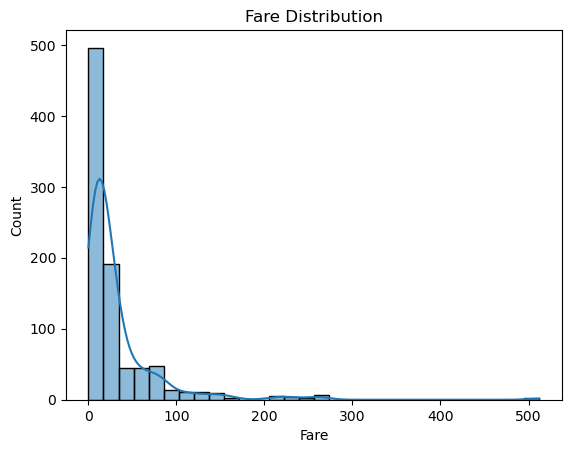

In [26]:
# Plotting distributions
plt.figure(figsize=(12, 6))
sns.histplot(titanic['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.show()

sns.histplot(titanic['Fare'], kde=True, bins=30)
plt.title('Fare Distribution')
plt.show()


#6.2 Survival Rates Based on Features

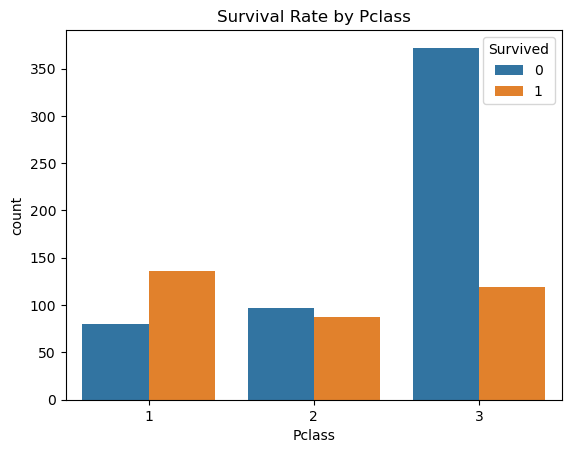

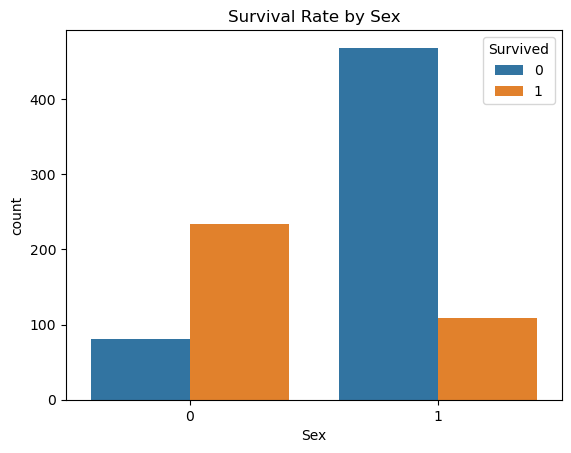

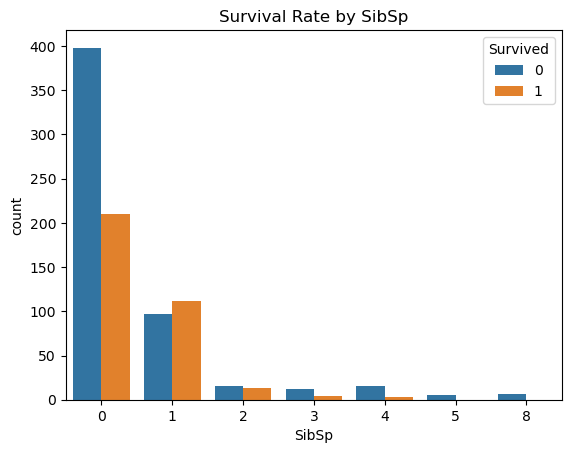

In [32]:
# Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=titanic)
plt.title('Survival Rate by Pclass')
plt.show()

# Survival by Sex
sns.countplot(x='Sex', hue='Survived', data=titanic)
plt.title('Survival Rate by Sex')
plt.show()

# Survival by SibSp (Number of siblings/spouses aboard)
sns.countplot(x='SibSp', hue='Survived', data=titanic)
plt.title('Survival Rate by SibSp')
plt.show()


# Step 7: Correlation Heatmap

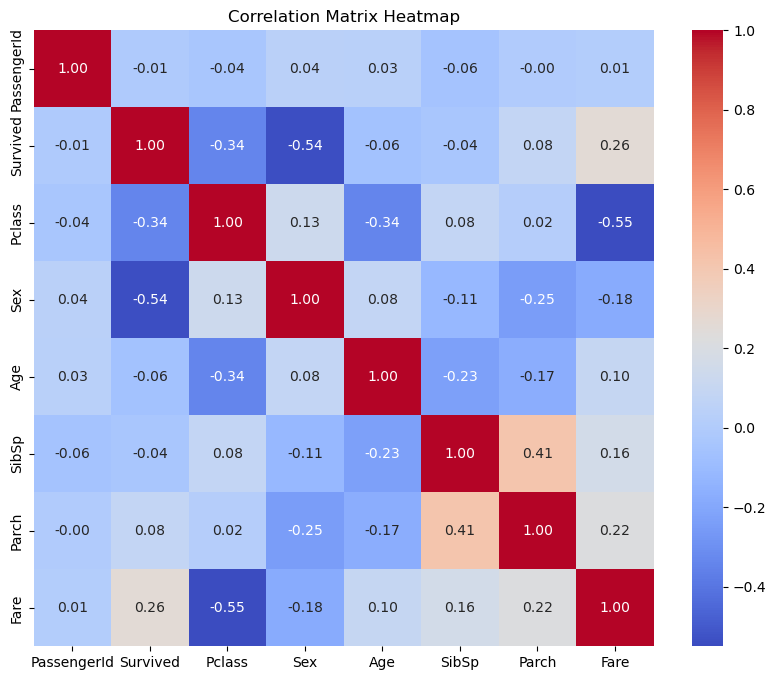

In [37]:
# Select only numeric columns
numeric_columns = titanic.select_dtypes(include=[np.number])

# Calculate the correlation matrix
corr = numeric_columns.corr()

# Plotting the heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()


# Step 8: Model Building (Optional)

#1-Split the Data into Training and Testing Sets:

In [41]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = titanic.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = titanic['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#2-Train a Logistic Regression Model:

In [48]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
titanic = pd.read_csv(r'C:\Users\yashp\titanic.csv')  # Adjust the path as needed

# Handle missing values
# Only fill missing values for numeric columns
numeric_columns = titanic.select_dtypes(include=['float64', 'int64']).columns
titanic[numeric_columns] = titanic[numeric_columns].fillna(titanic[numeric_columns].mean())

# Feature selection (this will depend on your dataset structure)
# Assuming you have already preprocessed the features and target variable
X = titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]  # Example features
y = titanic['Survived']  # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression model with increased max_iter and solver 'liblinear'
model = LogisticRegression(solver='liblinear', max_iter=1000)  # Increased max_iter
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 0.7318
Confusion Matrix:
[[94 11]
 [37 37]]


In [50]:
titanic.to_csv('titanic_cleaned.csv', index=False)
